In [2]:
import pandas as pd

df = pd.read_csv('../data/OnlineRetail.csv', encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df = df.dropna(subset=['CustomerID'])

In [5]:
df.shape

(406829, 8)

In [6]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
df.shape

(397924, 8)

In [8]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [12]:
snapshot_date = df['InvoiceDate'].max()

snapshot_date

Timestamp('2011-12-09 12:50:00')

In [13]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [14]:
rfm.shape

(4338, 4)

In [15]:
rfm['Recency'].describe()

count    4338.000000
mean       91.536422
std       100.014169
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       373.000000
Name: Recency, dtype: float64

In [16]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

In [17]:
rfm['Churn'].value_counts()

Churn
0    2893
1    1445
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [19]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

In [20]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

wcss

[13014.000000000007,
 9356.502998161328,
 5498.006250886908,
 4092.144305254269,
 3141.1018377167884,
 2472.6374320470954,
 2022.5081415167947,
 1798.303604043616,
 1466.1580454703392,
 1305.0204208846585]

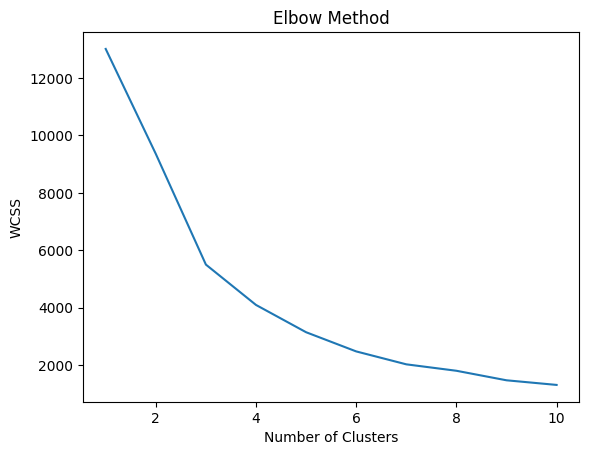

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Churn,Cluster
0,12346.0,325,1,77183.60,1,3
1,12347.0,1,7,4310.00,0,0
2,12348.0,74,4,1797.24,0,0
3,12349.0,18,1,1757.55,0,0
4,12350.0,309,1,334.40,1,1


In [23]:
rfm['Cluster'].value_counts()

Cluster
0    3060
1    1063
3     203
4       6
2       6
Name: count, dtype: int64

In [24]:
import numpy as np

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts()

Cluster
2    1228
3    1065
1     951
0     802
4     292
Name: count, dtype: int64

In [27]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Churn': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary,Churn
Cluster,,,,
0,22.15,1.75,425.98,0.00
1,20.04,6.31,2466.52,0.01
2,200.49,1.19,266.14,0.79
3,104.75,2.98,1360.33,0.43
4,8.57,22.23,15234.71,0.00


In [28]:
def segment_label(cluster):
    if cluster == 4:
        return 'Champions'
    elif cluster == 1:
        return 'Loyal Customers'
    elif cluster == 0:
        return 'New Customers'
    elif cluster == 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['Cluster'].apply(segment_label)

In [29]:
rfm['Segment'].value_counts()

Segment
Lost               1228
At Risk            1065
Loyal Customers     951
New Customers       802
Champions           292
Name: count, dtype: int64

In [30]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue

Segment
Champions          4448536.630
Loyal Customers    2345661.560
At Risk            1448746.193
New Customers       341637.830
Lost                326825.691
Name: Monetary, dtype: float64

In [31]:
segment_percent = (segment_revenue / segment_revenue.sum()) * 100

segment_percent.round(2)

Segment
Champions          49.92
Loyal Customers    26.32
At Risk            16.26
New Customers       3.83
Lost                3.67
Name: Monetary, dtype: float64

In [32]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.9896313364055299

In [37]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[561,   0],
       [  9, 298]], dtype=int64)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       561
           1       1.00      0.97      0.99       307

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [39]:
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [43]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.7131336405529954

In [44]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[449, 112],
       [137, 170]], dtype=int64)

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868



In [46]:
rfm['Churn_Probability'] = model.predict_proba(
    scaler.transform(rfm[['Frequency', 'Monetary']])
)[:, 1]

In [47]:
rfm[['CustomerID', 'Churn', 'Churn_Probability']].head()

,CustomerID,Churn,Churn_Probability
0,12346.0,1,0.378639
1,12347.0,0,0.066201
2,12348.0,0,0.216680
3,12349.0,0,0.514541
4,12350.0,1,0.517149


In [48]:
high_risk = rfm[rfm['Churn_Probability'] > 0.5]

high_risk.shape

(1492, 8)

In [49]:
revenue_at_risk = high_risk['Monetary'].sum()

revenue_at_risk

539128.131

## Retention Campaign ROI Simulation

In [50]:
campaign_cost_per_customer = 50
recovery_rate = 0.20

target_customers = high_risk.shape[0]

campaign_cost = target_customers * campaign_cost_per_customer
expected_recovery = revenue_at_risk * recovery_rate

net_gain = expected_recovery - campaign_cost

campaign_cost, expected_recovery, net_gain

(74600, 107825.62620000001, 33225.62620000001)

In [51]:
retention_targets = rfm[
    (rfm['Churn_Probability'] > 0.5) &
    (rfm['Segment'].isin(['At Risk', 'Loyal Customers']))
]

retention_targets.shape

(109, 8)

In [52]:
vip_targets = rfm[
    (rfm['Segment'] == 'Champions') &
    (rfm['Churn_Probability'] < 0.3)
]
vip_targets.shape

(292, 8)

In [53]:
lost_cause = rfm[
    (rfm['Segment'] == 'Lost') &
    (rfm['Churn_Probability'] > 0.45)
]

lost_cause.shape

(1028, 8)

In [54]:
rfm.to_csv('../data/customer_segmentation_output.csv', index=False)

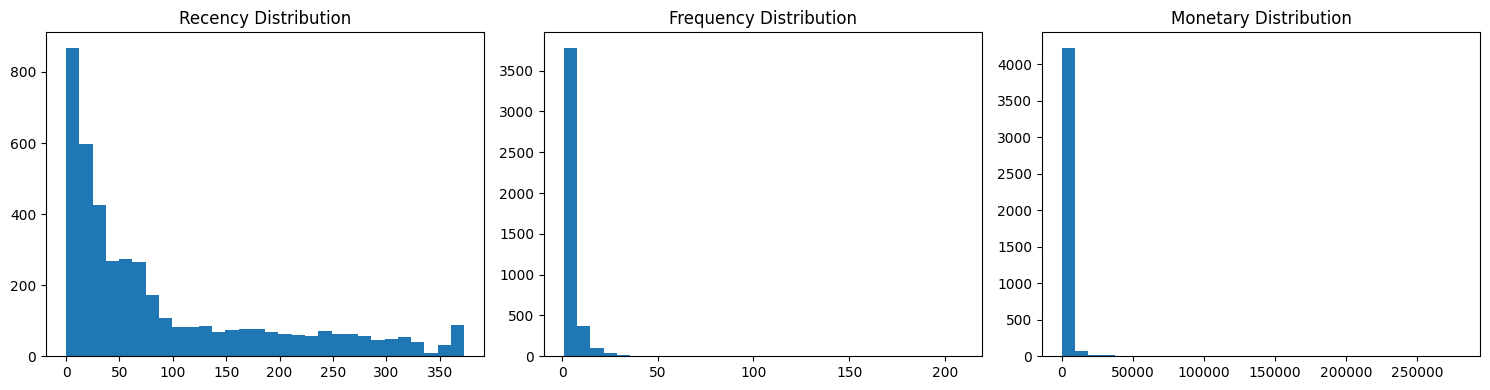

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(rfm['Recency'], bins=30)
plt.title('Recency Distribution')

plt.subplot(1,3,2)
plt.hist(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
plt.hist(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.savefig('../images/rfm_distribution.png')
plt.show()

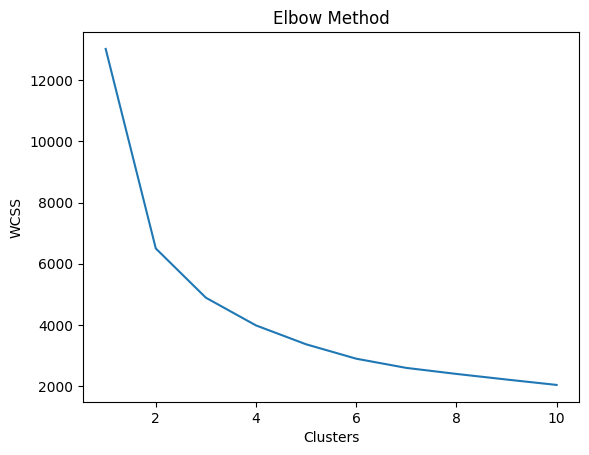

In [58]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.savefig('../images/elbow_method.png')
plt.show()

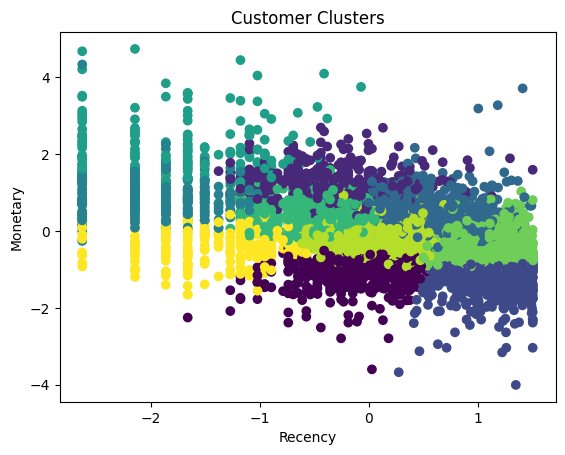

In [59]:
plt.scatter(rfm_scaled[:,0], rfm_scaled[:,2], c=kmeans.labels_)
plt.title('Customer Clusters')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.savefig('../images/cluster_visualization.png')
plt.show()